# Pandas Refresher Lab

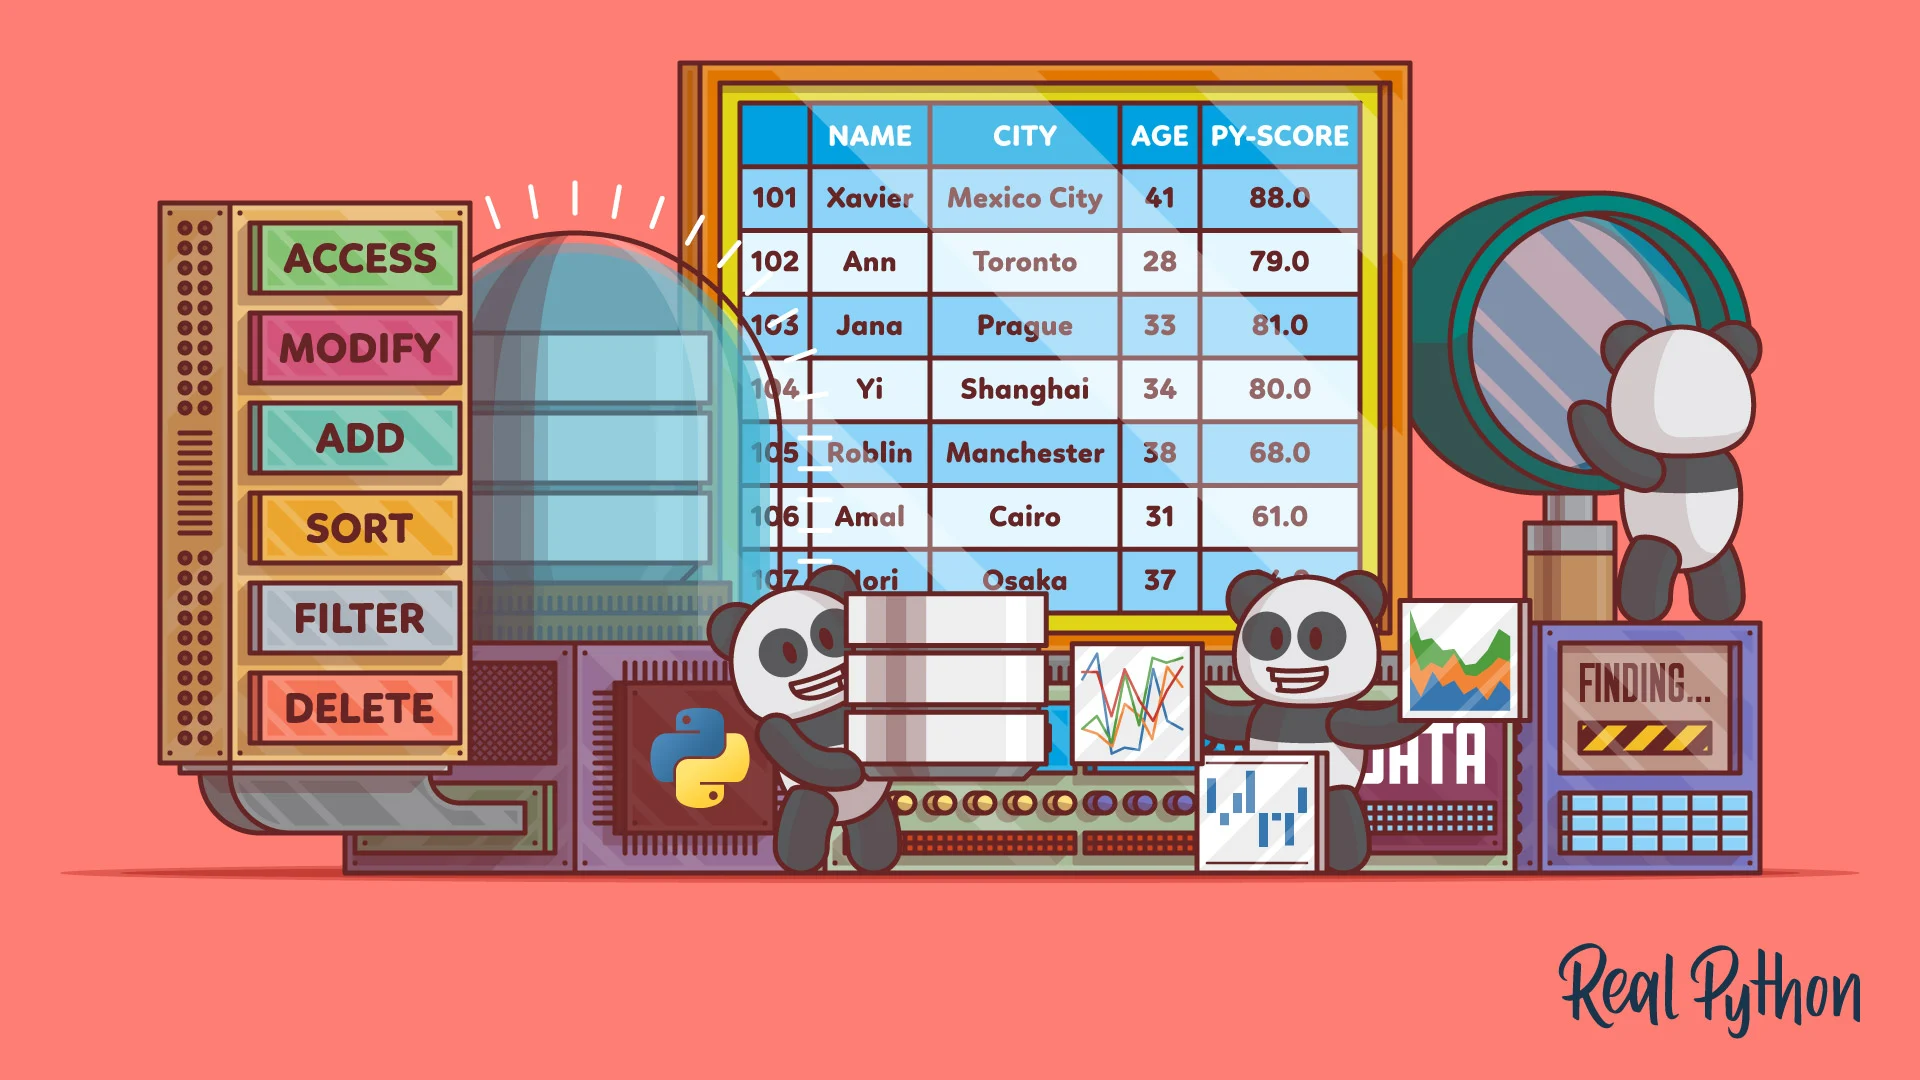

#### Exercises built from dataset used for PyCon 2018 presentation by Kevin Markham


### 1. Import pandas and check the version.

In [2]:
import pandas as pd
pd.show_versions()

c:\ProgramData\anaconda3\Lib\site-packages\_distutils_hack\__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")



INSTALLED VERSIONS
------------------
commit           : 0f437949513225922d851e9581723d82120684a6
python           : 3.11.5.final.0
python-bits      : 64
OS               : Windows
OS-release       : 10
Version          : 10.0.26100
machine          : AMD64
processor        : AMD64 Family 25 Model 80 Stepping 0, AuthenticAMD
byteorder        : little
LC_ALL           : None
LANG             : None
LOCALE           : English_United States.1252

pandas           : 2.0.3
numpy            : 1.24.3
pytz             : 2023.3.post1
dateutil         : 2.8.2
setuptools       : 68.0.0
pip              : 23.2.1
Cython           : None
pytest           : 7.4.0
hypothesis       : None
sphinx           : 5.0.2
blosc            : None
feather          : None
xlsxwriter       : None
lxml.etree       : 4.9.3
html5lib         : None
pymysql          : None
psycopg2         : None
jinja2           : 3.1.2
IPython          : 8.15.0
pandas_datareader: None
bs4              : 4.12.2
bottleneck       : 1.3.

### 2. Import matplotlib and specify inline usage.

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

## Dataset: Stanford Open Policing Project

https://openpolicing.stanford.edu/

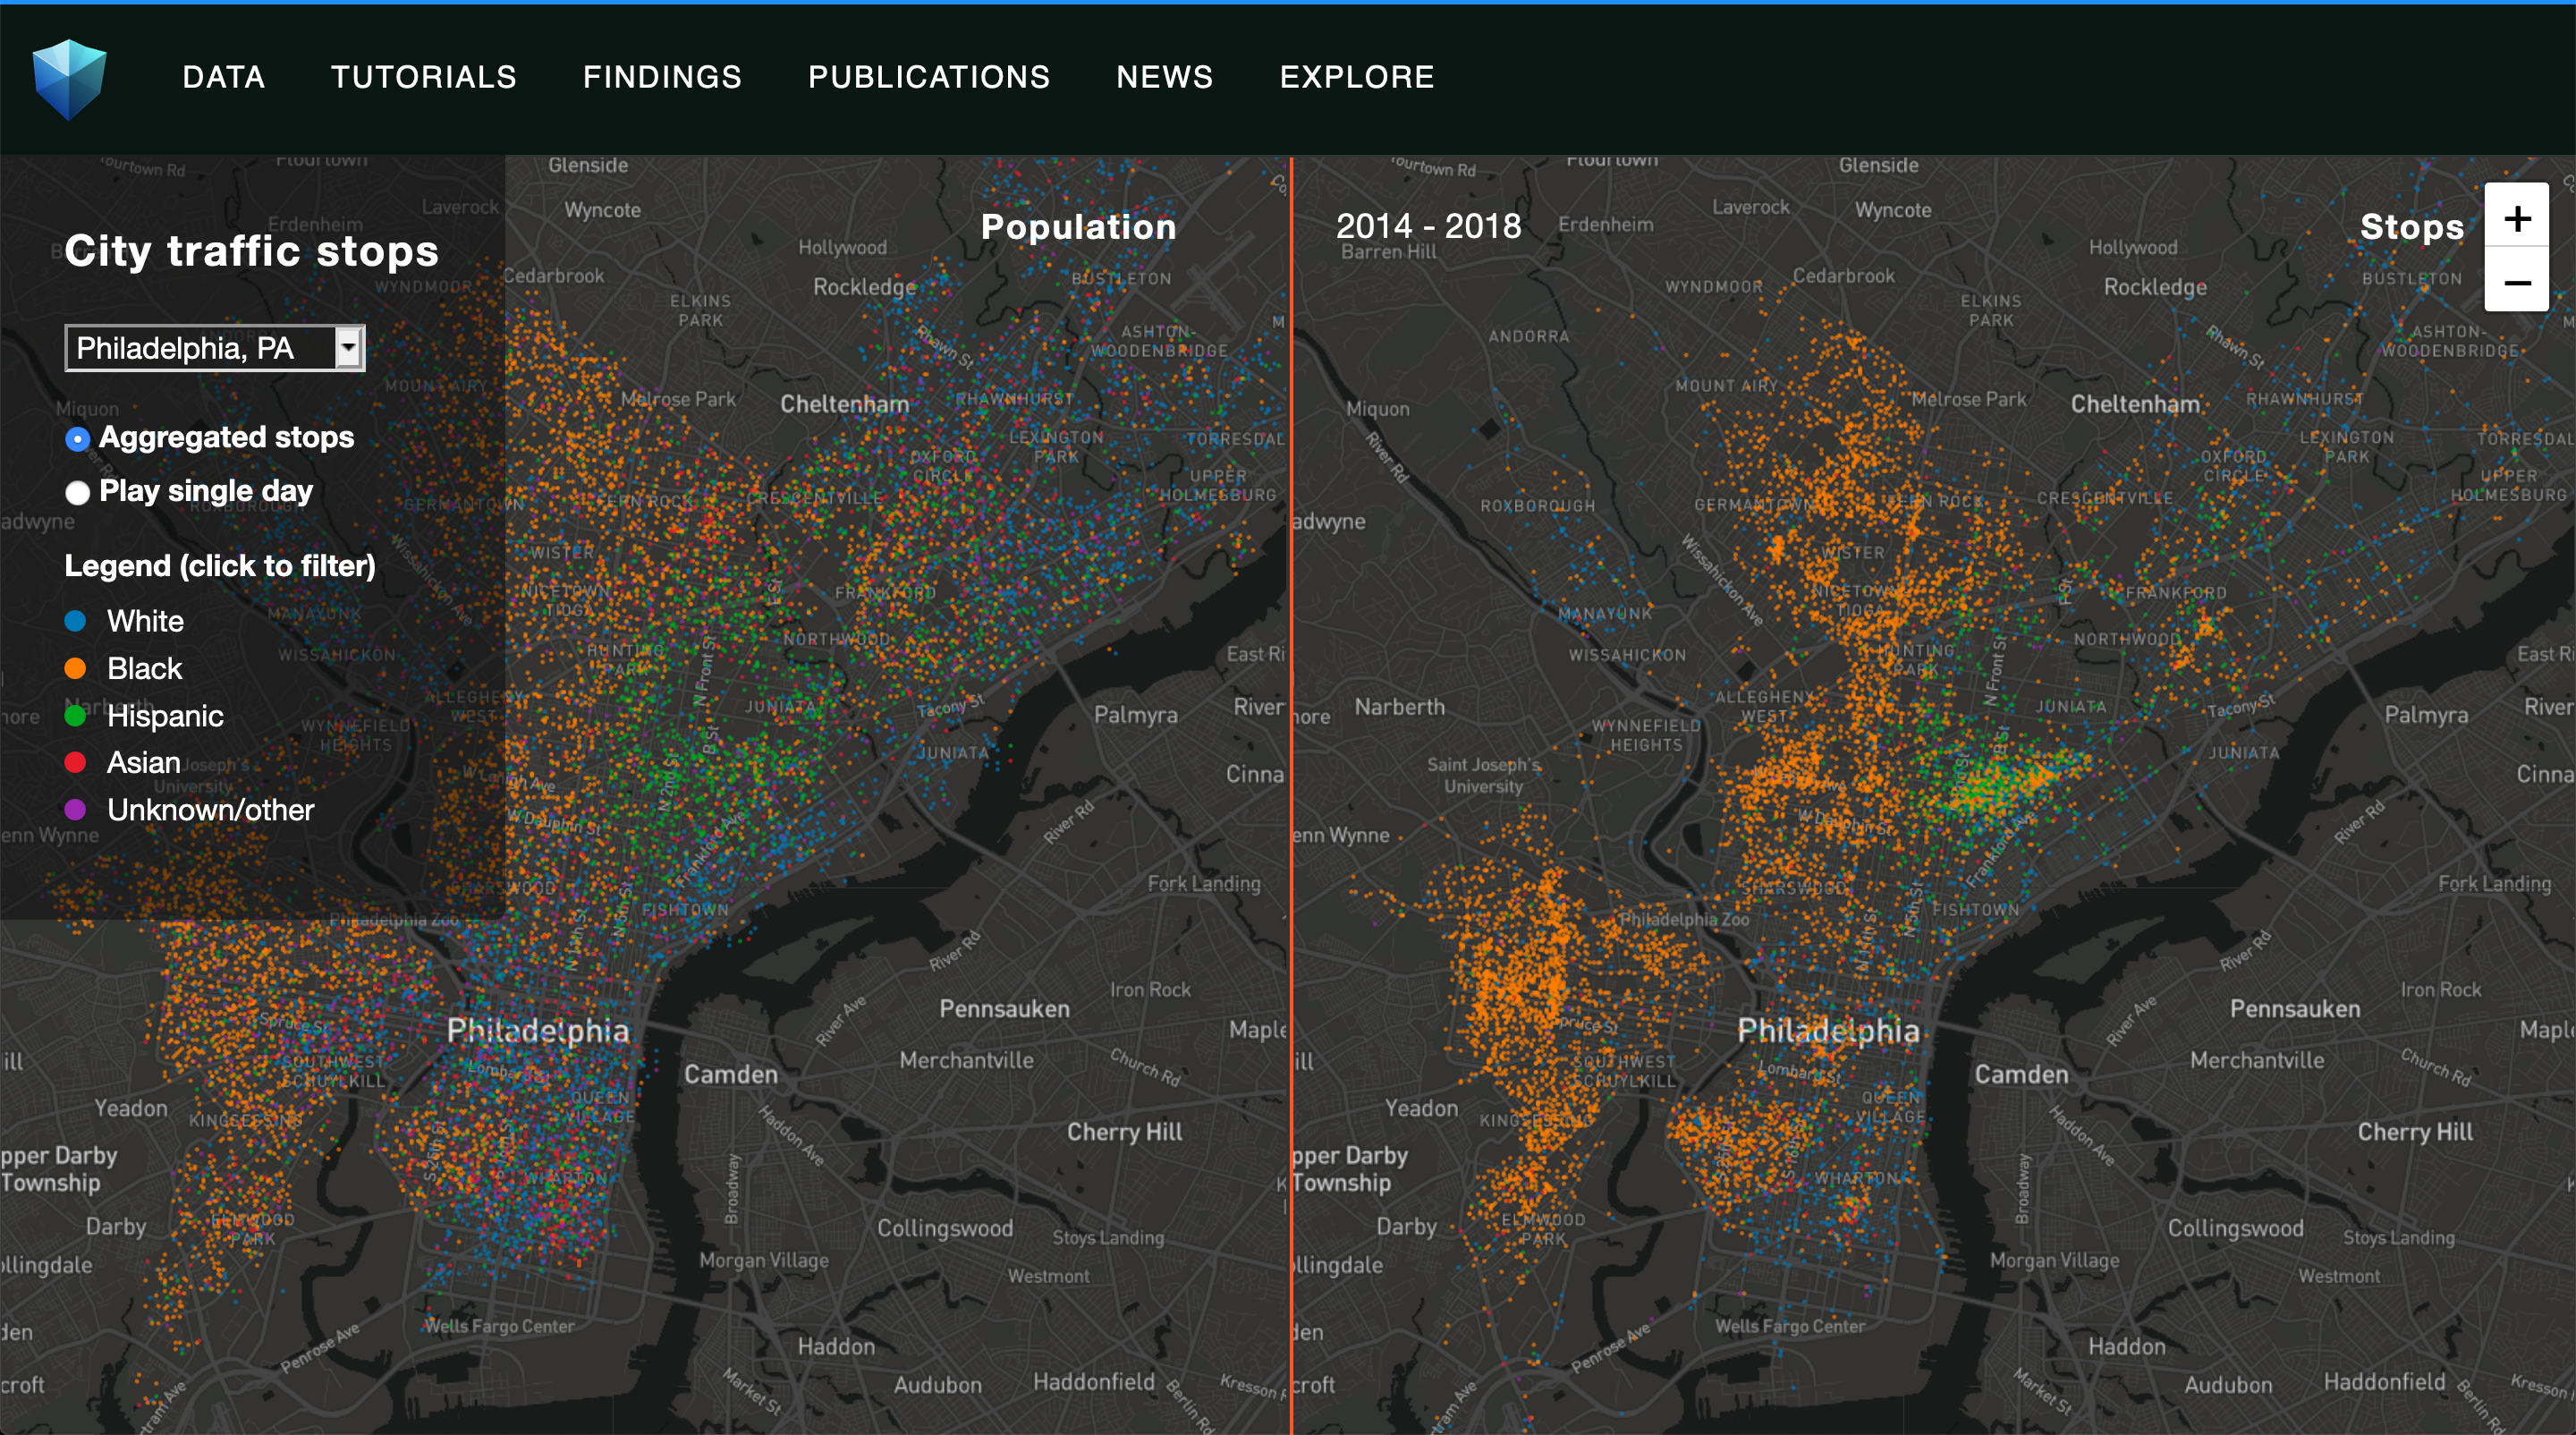

### 3. Read the police csv into a dataframe.

In [4]:
pol = pd.read_csv('./data/police.csv', sep=',')

### 4. Use the head command to print the first five rows.

In [5]:
pol.head()

,stop_date,stop_time,county_name,driver_gender,driver_age_raw,driver_age,driver_race,violation_raw,violation,search_conducted,search_type,stop_outcome,is_arrested,stop_duration,drugs_related_stop
0,2005-01-02,01:55,NaN,M,1985.0,20.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False
1,2005-01-18,08:15,NaN,M,1965.0,40.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False
2,2005-01-23,23:15,NaN,M,1972.0,33.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False
3,2005-02-20,17:15,NaN,M,1986.0,19.0,White,Call for Service,Other,False,NaN,Arrest Driver,True,16-30 Min,False
4,2005-03-14,10:00,NaN,F,1984.0,21.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False


### 5. Determine the shape of the dataframe.

In [6]:
pol.shape

(91741, 15)

### 6. Determine the data type of each column.

In [7]:
pol.dtypes

stop_date              object
stop_time              object
county_name           float64
driver_gender          object
driver_age_raw        float64
driver_age            float64
driver_race            object
violation_raw          object
violation              object
search_conducted         bool
search_type            object
stop_outcome           object
is_arrested            object
stop_duration          object
drugs_related_stop       bool
dtype: object

### 7. Print out the number of null (missing) values in each column.

In [8]:
pol.isna().sum()

stop_date                 0
stop_time                 0
county_name           91741
driver_gender          5335
driver_age_raw         5327
driver_age             5621
driver_race            5333
violation_raw          5333
violation              5333
search_conducted          0
search_type           88545
stop_outcome           5333
is_arrested            5333
stop_duration          5333
drugs_related_stop        0
dtype: int64

### 8. Remove the column that only contains missing values.

In [9]:
del pol['county_name']

### 9. Print out the shape of the updated dataframe.

In [10]:
pol.shape

(91741, 14)

### 10. Print out a list of the dataframe columns.

In [11]:
pol.columns

Index(['stop_date', 'stop_time', 'driver_gender', 'driver_age_raw',
       'driver_age', 'driver_race', 'violation_raw', 'violation',
       'search_conducted', 'search_type', 'stop_outcome', 'is_arrested',
       'stop_duration', 'drugs_related_stop'],
      dtype='object')

### 11. Determine the number of speeding violations by gender.

In [12]:
spe = pol[pol['violation'] == 'Speeding']
pd.DataFrame(spe.groupby('driver_gender')['violation'].count())

,violation
driver_gender,
F,15482
M,32979


### 12. When a man is pulled over, what percent of the time is it for speeding?

In [13]:
manspeeding =  pol[(pol['driver_gender'] == 'M') & (pol['violation'] == 'Speeding')]
justman = pol[pol['driver_gender'] == 'M']
percentyman = (len(manspeeding))/len(justman)
print (percentyman*100)

52.43501073217267


### 13. When a woman is pulled over, what percent of the time is it for speeding?

In [14]:
womspeeding =  pol[(pol['driver_gender'] == 'F') & (pol['violation'] == 'Speeding')]
justwom = pol[pol['driver_gender'] == 'F']
percentywom = (len(womspeeding))/len(justwom)
print (percentywom*100)

65.85002764663349


### 14. Use a groupby to determine the percentage of violation type for each gender.

For example, the distribution for women might be 80% speeding, 10% seat belt, and 10% moving violation.

In [15]:
pd.DataFrame(pol.groupby('driver_gender')['violation'].value_counts(normalize=True)*100)

proportion
driver_gender violation                      
F             Speeding              65.850028
              Moving violation      13.627664
              Equipment             10.578027
              Registration/plates    4.308621
              Other                  2.934796
              Seat belt              2.700863
M             Speeding              52.435011
              Moving violation      20.701169
              Equipment             13.567056
              Other                  5.766754
              Registration/plates    3.846093
              Seat belt              3.683918

### 15. Does gender affect who gets searched during a stop? Use a groupby or similar approach to compare.

In other words, what percent of the time does a male get searched during a stop? What about a female?

In [16]:
pd.DataFrame(pol.groupby('driver_gender')['search_conducted'].value_counts(normalize=True)*100)

proportion
driver_gender search_conducted            
F             False              97.996682
              True                2.003318
M             False              95.667382
              True                4.332618

### 16. What if one gender gets pulled over for violations that necessitate a search? Let's look at this another way. Determine the percentage of time that a driver is searched based on violation and then gender.

In [17]:
pd.DataFrame(pol.groupby(['violation','search_conducted'])['driver_gender'].value_counts(normalize=True)*100)


proportion
violation           search_conducted driver_gender            
Equipment           False            M               76.919349
                                     F               23.080651
                    True             M               84.943182
                                     F               15.056818
Moving violation    False            M               79.855176
                                     F               20.144824
                    True             M               87.039106
                                     F               12.960894
Other               False            M               84.149014
                                     F               15.850986
                    True             M               81.428571
                                     F               18.571429
Registration/plates False            M               69.464170
                                     F               30.535830
                    True             M               79.940120
                                     F               20.059880
Seat belt           False            M               78.046218
                                     F               21.953782
                    True             M               91.666667
                                     F                8.333333
Speeding            False            M               67.693247
                                     F               32.306753
                    True             M               85.893417
                                     F               14.106583

### 17. We next want to examine how often the driver is frisked, but this is a little tricky due to multiple search types in that field. First, do a value_counts on the search_type column.

In [18]:
pol['search_type'].value_counts()

search_type
Incident to Arrest                                          1219
Probable Cause                                               891
Inventory                                                    220
Reasonable Suspicion                                         197
Protective Frisk                                             161
Incident to Arrest,Inventory                                 129
Incident to Arrest,Probable Cause                            106
Probable Cause,Reasonable Suspicion                           75
Incident to Arrest,Inventory,Probable Cause                   34
Incident to Arrest,Protective Frisk                           33
Probable Cause,Protective Frisk                               33
Inventory,Probable Cause                                      22
Incident to Arrest,Reasonable Suspicion                       13
Inventory,Protective Frisk                                    11
Incident to Arrest,Inventory,Protective Frisk                 11
Protective Fr

### 18. Parse the strings in the search_type column to get a count of how many times each search type was part of the search conducted. 

For example, "Inventory,Reasonable Suspicion     4" should increase the count of both Inventory and Reasonable Suspicion by 4.

In [19]:
# this was vibe coded sorry 😔  
pol['split'] = pol['search_type'].str.split(',')
exploded = pol.explode('split')
exploded['split'].value_counts()


split
Incident to Arrest      1566
Probable Cause          1182
Inventory                439
Reasonable Suspicion     314
Protective Frisk         274
Name: count, dtype: int64

### 19. Create a new column called "frisk" that is true if the phrase "Protective Frisk" is in the search_type field and false if it is not.

In [20]:
def fris(search_type):
    if 'Protective Frisk' in search_type:
        return True
    else:
        return False

polclean = pol.dropna(subset = ['search_type'])
polclean['frisk'] = polclean['search_type'].apply(fris)
polclean.head()

C:\Users\EJacinto\AppData\Local\Temp\ipykernel_16604\2933920756.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  polclean['frisk'] = polclean['search_type'].apply(fris)


,stop_date,stop_time,driver_gender,driver_age_raw,driver_age,driver_race,violation_raw,violation,search_conducted,search_type,stop_outcome,is_arrested,stop_duration,drugs_related_stop,split,frisk
24,2005-08-28,01:00,M,1979.0,26.0,White,Other Traffic Violation,Moving violation,True,"Incident to Arrest,Protective Frisk",Arrest Driver,True,16-30 Min,False,"[Incident to Arrest, Protective Frisk]",True
40,2005-10-01,00:00,M,1988.0,17.0,White,Equipment/Inspection Violation,Equipment,True,Probable Cause,Arrest Driver,True,16-30 Min,True,[Probable Cause],False
41,2005-10-01,00:00,M,1988.0,17.0,White,Equipment/Inspection Violation,Equipment,True,Probable Cause,Citation,False,30+ Min,True,[Probable Cause],False
80,2005-10-02,09:30,M,1975.0,30.0,White,Speeding,Speeding,True,Incident to Arrest,Arrest Driver,True,30+ Min,False,[Incident to Arrest],False
106,2005-10-03,14:00,M,1978.0,27.0,Black,Equipment/Inspection Violation,Equipment,True,Probable Cause,Citation,False,16-30 Min,False,[Probable Cause],False


### 20. What percent of the time was a person frisked when a search was conducted?

In [21]:
frisktrue =  polclean[(polclean['frisk'] == True)]
percentfriskayy = (len(frisktrue))/len(polclean)
print (percentfriskayy*100)


8.573216520650814


### 21. How many stops were there in each of the years represented in this dataset?

In [22]:
def getyear(date):
    return date.split('-')[0]

pol['year'] = pol['stop_date'].apply(getyear)
pd.DataFrame(pol.groupby('year')['stop_date'].count())

,stop_date
year,
2005,2558
2006,10639
2007,9476
2008,8752
2009,7908
2010,7561
2011,8126
2012,10970
2013,7924


### 22. Why do you think one particular year's number of stops is so much lower than the rest?

I think 2005 is much lower than the rest because they started recording data near the end of the year.

### 23. What percent of the time is the stop related to drugs?

In [23]:
drugtrue =  pol[(pol['drugs_related_stop'] == True)]
percentdrugs = (len(drugtrue))/len(pol)
print (percentdrugs*100)

0.8883705213590434


### 24. How does this percentage of stops related to drugs vary over the course of a day?

In [24]:
def gethour(time):
    return time.split(':')[0]

pol['hour'] = pol['stop_time'].apply(gethour)
onlydrugs = pol[(pol['drugs_related_stop'] == True)]
pd.DataFrame(onlydrugs['hour'].value_counts(normalize = True)*100).sort_values(by = 'hour')

,proportion
hour,
00,12.638037
01,7.361963
02,5.644172
03,2.453988
04,0.368098
05,0.122699
06,1.226994
07,1.840491
08,1.717791


### 25. Make a basic plot of the drug related stop percentage by hour of the day.

<Axes: xlabel='hour'>

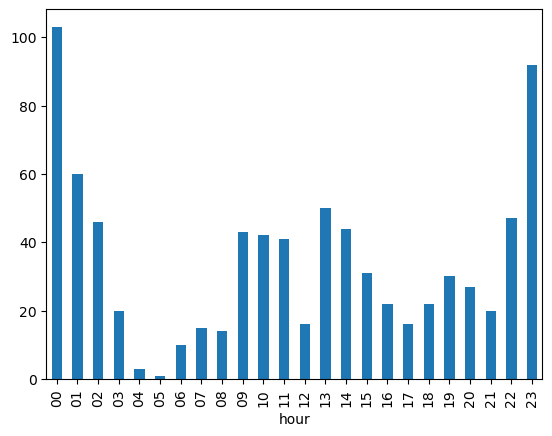

In [25]:
onlydrugs['hour'].value_counts().sort_index().plot(kind='bar')

### 26. Are there any surprises in the drug related percentage by hour plot?

Drug related stops dip at 12 but then get even higher at 1 for some reason. 

### 27. What are the five most common hours that people are stopped?

In [26]:
pol['hour'].value_counts()

hour
10    7350
09    6838
11    5877
14    5634
23    5629
00    5221
08    5210
13    4842
15    4832
07    4572
01    4442
16    3844
12    3582
22    3473
20    3340
06    3290
02    2975
17    2900
19    2587
18    2168
21    1499
03    1172
04     254
05     210
Name: count, dtype: int64

The most common hours that people are stopped are 10 am, 9 am, 11 am, 2 pm, and 11 pm. 

### 28. Compare the age distributions for each violation by grouping by violation and then using the describe function.

In [27]:
pol.groupby('violation')['driver_age'].describe()

,count,mean,std,min,25%,50%,75%,max
violation,,,,,,,,
Equipment,11007.0,31.781503,11.400900,16.0,23.0,28.0,38.0,89.0
Moving violation,16164.0,36.120020,13.185805,15.0,25.0,33.0,46.0,99.0
Other,4204.0,39.536870,13.034639,16.0,28.0,39.0,49.0,87.0
Registration/plates,3427.0,32.803035,11.033675,16.0,24.0,30.0,40.0,74.0
Seat belt,2952.0,32.206301,11.213122,17.0,24.0,29.0,38.0,77.0
Speeding,48361.0,33.530097,12.821847,15.0,23.0,30.0,42.0,90.0


### 29. Who is the oldest person to get a speeding violation in this dataset?

In [32]:
speedingtrue =  pol[(pol['violation'] == 'Speeding')]
old = speedingtrue.sort_values(by='driver_age', ascending = False)
old.head(1)

,stop_date,stop_time,driver_gender,driver_age_raw,driver_age,driver_race,violation_raw,violation,search_conducted,search_type,stop_outcome,is_arrested,stop_duration,drugs_related_stop,split,year,hour
76956,2014-04-25,16:40,M,1924.0,90.0,White,Speeding,Speeding,False,NaN,Warning,False,0-15 Min,False,NaN,2014,16


The oldest person to get a speeding violation was a 90 year old white male.

### 30. Use ChatGPT to write a story about why this person was speeding.

**Title: “Just a Warning”**

On April 25, 2014, at precisely 4:40 PM, Zachary Chippah, a 90-year-old retired schoolteacher from the sleepy town of Willow Bend, found himself pulled over by a local police officer for the first time in his long, law-abiding life.

Zachary had driven that same rust-colored 1983 Buick LeSabre since the Reagan administration. The car creaked like an old rocking chair and smelled faintly of pipe tobacco and peppermint, but it still ran — mostly. That Friday afternoon, Zachary was on his way to the VFW hall for their weekly bingo night when he accidentally rolled through a stop sign at the corner of Main and Sycamore.

Officer Daniels, fresh out of the academy and barely old enough to shave, approached the car with professional caution.

"License and registration, sir," he said, leaning toward the open window.

Zachary blinked at him over thick bifocals. "You sure you're old enough to be wearin’ that badge, son?"

Daniels tried to suppress a grin. "Yes, sir. You rolled through that stop sign back there. Do you know why I pulled you over?"

Zachary squinted. “You mean that old post with the red sign? I’ve been stopping there since before your mama was born. But alright, maybe I eased through. I’m 90, you know. My foot don’t always stop when my brain says so.”

Daniels took the license and registration, ran it through, and came back with a thoughtful look.

"Mr. Chippah, your record’s clean. I’m going to let you off with a warning today. Just try to come to a full stop next time, alright?"

Zachary chuckled, adjusting his World War II veteran cap. “Fair enough, officer. I’ll even give it a full Mississippi count next time.”

He put the car back in drive, gave a two-finger salute, and slowly crept away, the Buick groaning in protest.

Daniels stood at the curb, shaking his head and smiling.

Back at the VFW, Zachary told the story twice before the first bingo ball was even drawn — and every Friday after that for the next year.

---

**Moral of the story?** Sometimes age earns you a little grace — and a pretty good story to tell at bingo night.